In [1]:
#구글 마운트
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
#모델 불러오기
!cp -r /content/drive/MyDrive/font_project/mxfont /content/

In [4]:
import os

folder = "/content/mxfont/data/images/test_kor/myfont14"

for f in os.listdir(folder):
    os.remove(os.path.join(folder, f))

print("기존 이미지 삭제 완료")

기존 이미지 삭제 완료


In [5]:
from google.colab import files
uploaded = files.upload()

Saving 가.png to 가 (1).png
Saving 나.png to 나 (1).png
Saving 더.png to 더 (1).png
Saving 려.png to 려 (1).png
Saving 모.png to 모 (1).png
Saving 부.png to 부 (1).png
Saving 쇼.png to 쇼 (1).png
Saving 야.png to 야.png
Saving 져.png to 져 (1).png
Saving 쵸.png to 쵸 (1).png
Saving 켜.png to 켜 (1).png
Saving 튜.png to 튜 (1).png
Saving 프.png to 프 (1).png
Saving 히.png to 히 (1).png


In [9]:
import os
import cv2

folder = "/content/mxfont/data/images/test_kor/myfont14"

files = sorted(os.listdir(folder))

for f in files:
    path = os.path.join(folder, f)
    img = cv2.imread(path)

    if img is None:
        print("읽기 실패:", f)
        continue

    h, w = img.shape[:2]
    print(f, ":", w, "x", h)

가.png : 128 x 128
나.png : 128 x 128
더.png : 128 x 128
려.png : 128 x 128
모.png : 128 x 128
부.png : 128 x 128
쇼.png : 128 x 128
야.png : 128 x 128
져.png : 128 x 128
쵸.png : 128 x 128
켜.png : 128 x 128
튜.png : 128 x 128
프.png : 128 x 128
히.png : 128 x 128


In [ ]:
#전처리
import cv2
import os

folder = "/content/mxfont/data/images/test_kor/myfont14"

files = sorted(os.listdir(folder))

for f in files:

    path = os.path.join(folder, f)

    img = cv2.imread(path)

    if img is None:
        print("읽기 실패:", f)
        continue

    # grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # blur (노이즈 완화)
    blur = cv2.GaussianBlur(gray, (3,3), 0)

    # threshold (배경 정리)
    _, binary = cv2.threshold(blur, 200, 255, cv2.THRESH_BINARY)

    # 덮어쓰기 저장
    cv2.imwrite(path, binary)

    print("완료:", f)

print("전처리 완료")

완료: 가.png
완료: 나.png
완료: 더.png
완료: 려.png
완료: 모.png
완료: 부.png
완료: 쇼.png
완료: 야.png
완료: 져.png
완료: 쵸.png
완료: 켜.png
완료: 튜.png
완료: 프.png
완료: 히.png
전처리 완료


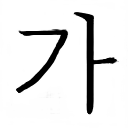

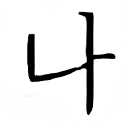

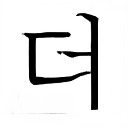

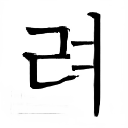

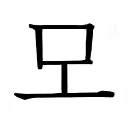

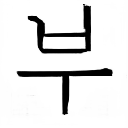

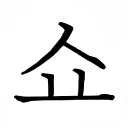

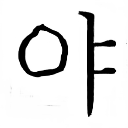

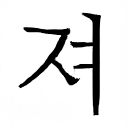

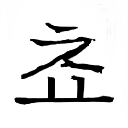

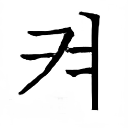

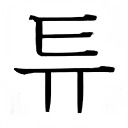

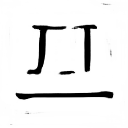

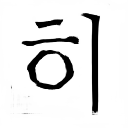

In [10]:
#전처리 결과 확인
from IPython.display import Image, display
import os

folder = "/content/mxfont/data/images/test_kor/myfont14"

for f in sorted(os.listdir(folder)):
    display(Image(filename=os.path.join(folder,f)))

In [11]:
#hangul_2780.txt를 json으로 변환
import json

json_path = "/content/mxfont/data/hangul_2780.json"

with open("/content/drive/MyDrive/font_project/hangul_2780.txt", "r", encoding="utf-8") as f:
    chars = f.read().split()

with open(json_path, "w", encoding="utf-8") as f:
    json.dump(chars, f, ensure_ascii=False)

print("json 저장 완료:", json_path)
print("글자 수:", len(chars))

json 저장 완료: /content/mxfont/data/hangul_2780.json
글자 수: 2780


In [12]:
eval_yaml = """
dset:
  test:
    data_dir: /content/mxfont/data/images/test_kor
    source_font: /content/mxfont/data/NanumGothic.ttf
    gen_chars_file: /content/mxfont/data/hangul_2780.json
"""

with open("/content/mxfont/cfgs/eval_kor_2780.yaml", "w", encoding="utf-8") as f:
    f.write(eval_yaml)

print(open("/content/mxfont/cfgs/eval_kor_2780.yaml", "r", encoding="utf-8").read())


dset:
  test:
    data_dir: /content/mxfont/data/images/test_kor
    source_font: /content/mxfont/data/NanumGothic.ttf
    gen_chars_file: /content/mxfont/data/hangul_2780.json



In [13]:
!pip install sconf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 6.7 MB/s eta 0:00:00


In [14]:
import os
import json

print("1. test_kor 존재:", os.path.exists("/content/mxfont/data/images/test_kor"))
print("2. myfont14 존재:", os.path.exists("/content/mxfont/data/images/test_kor/myfont14"))
print("3. myfont14 파일:", sorted(os.listdir("/content/mxfont/data/images/test_kor/myfont14")))

print("4. generator.pth 존재:", os.path.exists("/content/mxfont/generator.pth"))
print("5. NanumGothic.ttf 존재:", os.path.exists("/content/mxfont/data/NanumGothic.ttf"))
print("6. eval.py 존재:", os.path.exists("/content/mxfont/eval.py"))
print("7. yaml 존재:", os.path.exists("/content/mxfont/cfgs/eval_kor_2780.yaml"))
print("8. json 존재:", os.path.exists("/content/mxfont/data/hangul_2780.json"))

with open("/content/mxfont/data/hangul_2780.json", "r", encoding="utf-8") as f:
    chars = json.load(f)
print("9. 생성 글자 수:", len(chars))
print("10. 앞 20개:", chars[:20])

1. test_kor 존재: True
2. myfont14 존재: True
3. myfont14 파일: ['가.png', '나.png', '더.png', '려.png', '모.png', '부.png', '쇼.png', '야.png', '져.png', '쵸.png', '켜.png', '튜.png', '프.png', '히.png']
4. generator.pth 존재: True
5. NanumGothic.ttf 존재: True
6. eval.py 존재: True
7. yaml 존재: True
8. json 존재: True
9. 생성 글자 수: 2780
10. 앞 20개: ['가', '각', '간', '갇', '갈', '갉', '갊', '갋', '감', '갑', '값', '갓', '갔', '강', '갖', '갗', '같', '갚', '갛', '개']


In [16]:
import os
import unicodedata

folder = "/content/mxfont/data/images/test_kor/myfont14"

for name in os.listdir(folder):
    old_path = os.path.join(folder, name)
    new_name = unicodedata.normalize("NFC", name)
    new_path = os.path.join(folder, new_name)

    if old_path != new_path:
        os.rename(old_path, new_path)
        print(f"변경: {name} -> {new_name}")

print("파일명 NFC 정규화 완료")
print(sorted(os.listdir(folder)))

파일명 NFC 정규화 완료
['가.png', '나.png', '더.png', '려.png', '모.png', '부.png', '쇼.png', '야.png', '져.png', '쵸.png', '켜.png', '튜.png', '프.png', '히.png']


In [17]:
%cd /content/mxfont

!python eval.py cfgs/eval_kor_2780.yaml \
--weight generator.pth \
--result_dir results_kor_2780 \
--batch_size 1

/content/mxfont


In [ ]:
import os
from PIL import Image
import matplotlib.pyplot as plt
import math

out_dir = "/content/mxfont/results_kor_2780/myfont14"
files = sorted(os.listdir(out_dir))

cols = 20
rows = math.ceil(len(files) / cols)

plt.figure(figsize=(20, rows))

for i, f in enumerate(files):
    img_path = os.path.join(out_dir, f)
    img = Image.open(img_path)

    plt.subplot(rows, cols, i + 1)
    plt.imshow(img, cmap="gray")
    plt.axis("off")

plt.tight_layout()
plt.show()

/tmp/ipykernel_396/2442917427.py:24: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_396/2442917427.py:24: UserWarning: Glyph 44033 (\N{HANGUL SYLLABLE GAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_396/2442917427.py:24: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_396/2442917427.py:24: UserWarning: Glyph 44039 (\N{HANGUL SYLLABLE GAD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_396/2442917427.py:24: UserWarning: Glyph 44040 (\N{HANGUL SYLLABLE GAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_396/2442917427.py:24: UserWarning: Glyph 44041 (\N{HANGUL SYLLABLE GALG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_396/2442917427.py:24: UserWarning: Glyph 44042 (\N{HANGUL SYLLABLE GALM}) missing from font(s) DejaVu Sans.
  plt.tight_layout(

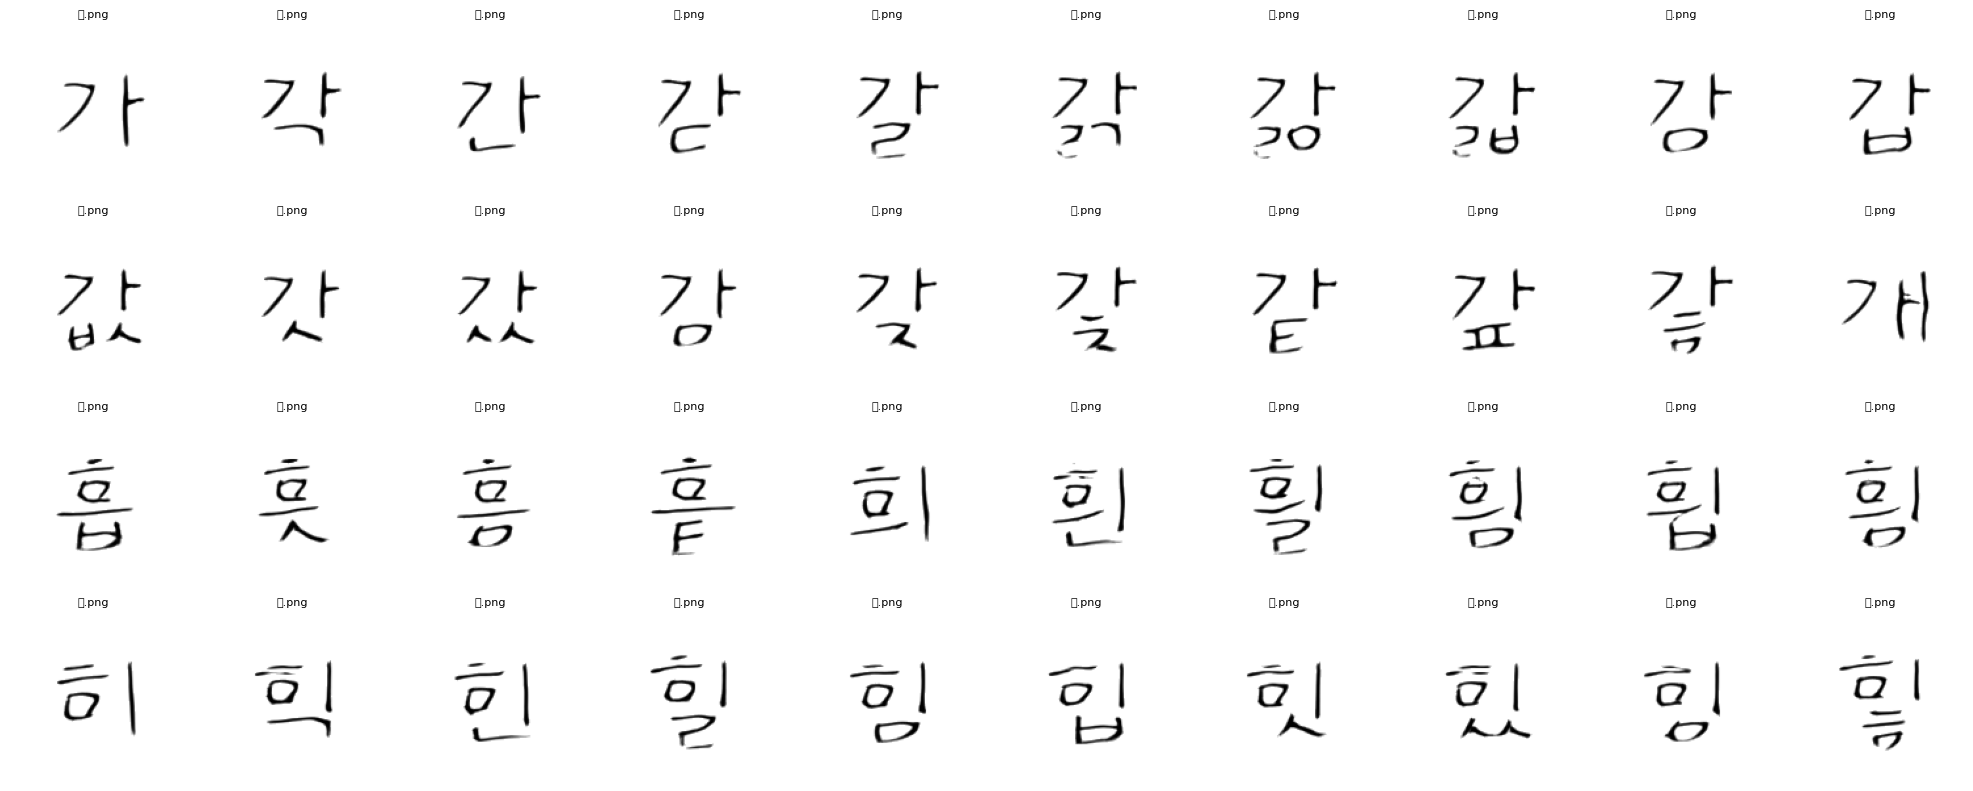

In [ ]:
import os
from PIL import Image
import matplotlib.pyplot as plt

out_dir = "/content/mxfont/results_kor_2780/myfont14"
files = sorted(os.listdir(out_dir))

show_files = files[:20] + files[-20:]

rows = 4
cols = 10

plt.figure(figsize=(20, 8))

for i, f in enumerate(show_files):
    img_path = os.path.join(out_dir, f)
    img = Image.open(img_path)

    plt.subplot(rows, cols, i + 1)
    plt.imshow(img, cmap="gray")
    plt.title(f, fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import os

files=os.listdir("/content/mxfont/results_kor_2780/myfont14")
print("생성된 글자:",len(files))

생성된 글자: 2780


In [ ]:
!apt-get update
!apt-get install potrace -y

Hit:1 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:2 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:3 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:4 https://cli.github.com/packages stable InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:6 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:7 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Hit:11 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading packag

In [ ]:
!apt-get install imagemagick -y

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  fonts-droid-fallback fonts-noto-mono fonts-urw-base35 ghostscript gsfonts
  imagemagick-6-common imagemagick-6.q16 libdjvulibre-text libdjvulibre21
  libfftw3-double3 libgs9 libgs9-common libidn12 libijs-0.35 libilmbase25
  libjbig2dec0 libjxr-tools libjxr0 liblqr-1-0 libmagickcore-6.q16-6
  libmagickcore-6.q16-6-extra libmagickwand-6.q16-6 libnetpbm10 libopenexr25
  libwmflite-0.2-7 netpbm poppler-data
Suggested packages:
  fonts-noto fonts-freefont-otf | fonts-freefont-ttf fonts-texgyre
  ghostscript-x imagemagick-doc autotrace cups-bsd | lpr | lprng enscript gimp
  gnuplot grads hp2xx html2ps libwmf-bin mplayer povray radiance sane-utils
  texlive-base-bin transfig ufraw-batch libfftw3-bin libfftw3-dev inkscape
  poppler-utils fonts-japanese-mincho | fonts-ipafont-mincho
  fonts-japanese-gothic | fonts-ipafont-gothic fonts-arphic-uka

In [ ]:
import os
import subprocess

png_dir = "/content/mxfont/results_kor_2780/myfont14"
svg_dir = "/content/mxfont/results_kor_2780/myfont14_svg"
pbm_dir = "/content/mxfont/results_kor_2780/myfont14_pbm"

os.makedirs(svg_dir, exist_ok=True)
os.makedirs(pbm_dir, exist_ok=True)

files = sorted([f for f in os.listdir(png_dir) if f.lower().endswith(".png")])

for f in files:
    png_path = os.path.join(png_dir, f)
    name = os.path.splitext(f)[0]

    pbm_path = os.path.join(pbm_dir, name + ".pbm")
    svg_path = os.path.join(svg_dir, name + ".svg")

    # PNG → PBM (흑백 변환)
    subprocess.run([
        "convert",
        png_path,
        "-threshold", "70%",
        "-background", "white",
        "-alpha", "remove",
        pbm_path
    ], check=True)

    # PBM → SVG (벡터화)
    subprocess.run([
        "potrace",
        pbm_path,
        "-s",
        "-o",
        svg_path
    ], check=True)

print("PNG -> SVG 벡터화 완료")
print("SVG 개수:", len(os.listdir(svg_dir)))

PNG -> SVG 벡터화 완료
SVG 개수: 2780


In [ ]:
!cp /content/mxfont/data/NanumGothic.ttf /content/base_nanummod.ttf

In [ ]:
script = r"""
import fontforge
import os
import unicodedata
import psMat

base_font_path = "/content/base_nanummod.ttf"
svg_dir = "/content/mxfont/results_kor_2780/myfont14_svg"
output_ttf = "/content/CEHandKRFinal.ttf"

font = fontforge.open(base_font_path)

# 기본 이름 지정
font.fontname = "CEHandKRFinal-Regular"
font.familyname = "CE Hand KR Final"
font.fullname = "CE Hand KR Final Regular"
font.weight = "Regular"
font.version = "1.0"
font.copyright = "Custom handwritten font based on modified base font."

# 기존 name table 덮어쓰기용
name_records = [
    ("English (US)", "Family", "CE Hand KR Final"),
    ("English (US)", "SubFamily", "Regular"),
    ("English (US)", "Fullname", "CE Hand KR Final Regular"),
    ("English (US)", "PostScriptName", "CEHandKRFinal-Regular"),
    ("English (US)", "Preferred Family", "CE Hand KR Final"),
    ("English (US)", "Preferred Styles", "Regular"),
    ("English (US)", "Compatible Full", "CE Hand KR Final Regular"),
    ("English (US)", "UniqueID", "CEHandKRFinal-Regular-1.0"),

    ("Korean", "Family", "채은손글씨"),
    ("Korean", "SubFamily", "Regular"),
    ("Korean", "Fullname", "채은손글씨 Regular"),
    ("Korean", "Preferred Family", "채은손글씨"),
    ("Korean", "Preferred Styles", "Regular"),
    ("Korean", "Compatible Full", "채은손글씨 Regular"),
]

for lang, key, value in name_records:
    try:
        font.appendSFNTName(lang, key, value)
    except:
        pass

files = sorted([f for f in os.listdir(svg_dir) if f.lower().endswith(".svg")])

count = 0

TARGET_SCALE = 1.90
TARGET_WIDTH_RATIO = 1.50

for f in files:
    char = os.path.splitext(f)[0]
    char = unicodedata.normalize("NFC", char)

    if len(char) != 1:
        continue

    codepoint = ord(char)
    glyph = font[codepoint]
    original_width = glyph.width

    glyph.clear()
    glyph.importOutlines(os.path.join(svg_dir, f))

    try:
        glyph.removeOverlap()
    except:
        pass

    try:
        glyph.correctDirection()
    except:
        pass

    glyph.transform(psMat.scale(TARGET_SCALE, TARGET_SCALE))

    try:
        glyph.removeOverlap()
    except:
        pass

    xmin, ymin, xmax, ymax = glyph.boundingBox()
    glyph_w = xmax - xmin

    target_advance = int(original_width * TARGET_WIDTH_RATIO)
    if target_advance < 700:
        target_advance = 700

    dx = (target_advance - glyph_w) / 2 - xmin

    target_center_y = 360
    current_center_y = (ymin + ymax) / 2
    dy = target_center_y - current_center_y

    glyph.transform(psMat.translate(dx, dy))
    glyph.width = target_advance

    count += 1
    if count % 200 == 0:
        print("진행:", count)

space = font[32]
space.width = 300

font.ascent = 920
font.descent = 180

font.os2_typoascent = 920
font.os2_typodescent = -180
font.os2_winascent = 920
font.os2_windescent = 180

font.hhea_ascent = 920
font.hhea_descent = -180
font.hhea_linegap = 0

font.generate(output_ttf)

print("완료:", output_ttf)
print("덮어쓴 글리프 수:", count)
"""

with open("/content/makefont_namefix.py", "w", encoding="utf-8") as f:
    f.write(script)

print("스크립트 저장 완료")

스크립트 저장 완료


In [ ]:
!fontforge -script /content/makefont_namefix.py

Copyright (c) 2000-2024. See AUTHORS for Contributors.
 License GPLv3+: GNU GPL version 3 or later <http://gnu.org/licenses/gpl.html>
 with many parts BSD <http://fontforge.org/license.html>. Please read LICENSE.
 Version: 20201107
 Based on sources from 2024-06-24 13:55 UTC-ML-D-GDK3.
PythonUI_Init()
copyUIMethodsToBaseTable()
The following table(s) in the font have been ignored by FontForge
  Ignoring 'DSIG' digital signature table
Internal Error (overlap) in uniACAF: The start of the monotonic does not match that of the containing spline.
Internal Error (overlap) in uniACB8: The start of the monotonic does not match that of the containing spline.
Internal Error (overlap) in uniAE08: The start of the monotonic does not match that of the containing spline.
Internal Error (overlap) in uniAE11: The start of the monotonic does not match that of the containing spline.
진행: 200
Internal Error (overlap) in uniAF48: The start of the monotonic does not match that of the containing spline.
진행: 

In [ ]:
import os

font_path = "/content/CEHandKRFinal.ttf"
print("파일 존재:", os.path.exists(font_path))
print("파일 크기:", os.path.getsize(font_path) if os.path.exists(font_path) else "없음")

파일 존재: True
파일 크기: 1960304


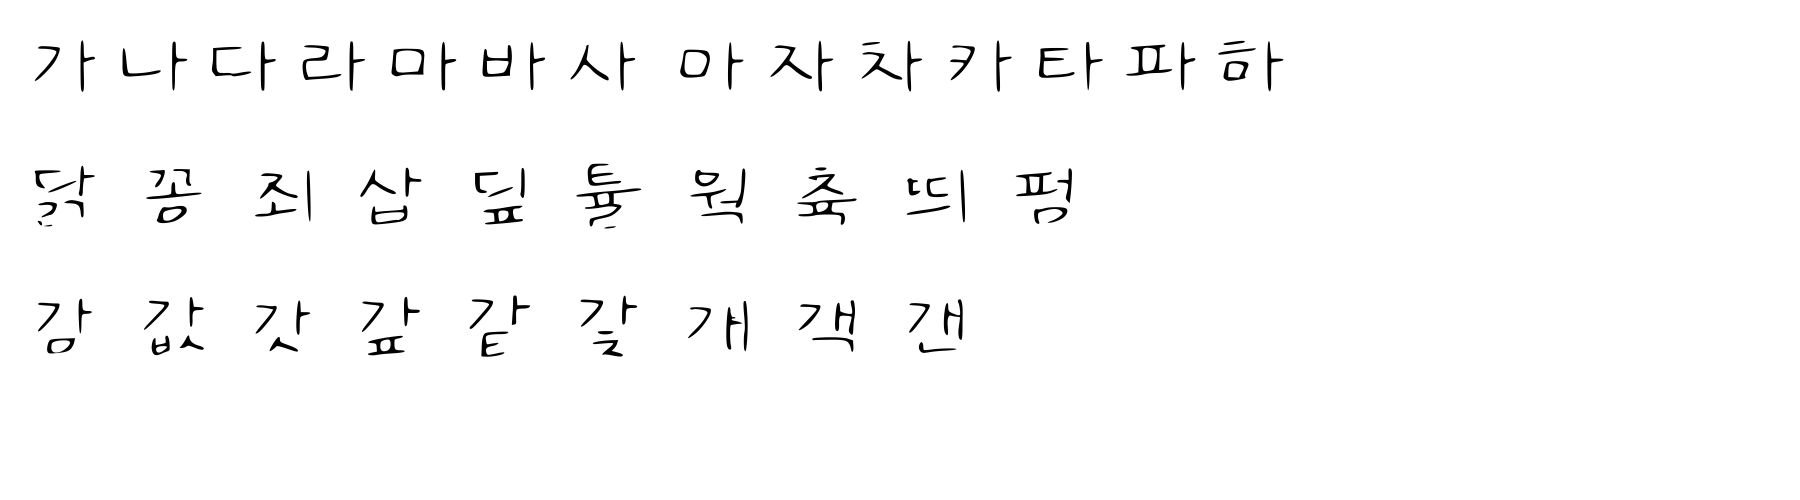

In [ ]:
from PIL import Image, ImageDraw, ImageFont
from IPython.display import display

font_path = "/content/CEHandKRFinal.ttf"

texts = [
    "가나다라마바사 아자차카타파하",
    "닭 꽁 죄 삽 딮 튤 웍 츅 띄 펌",
    "강 값 갓 갚 같 갗 개 객 갠"
]

img = Image.new("RGB", (1800, 500), "white")
draw = ImageDraw.Draw(img)
font = ImageFont.truetype(font_path, 70)

y = 30
for t in texts:
    draw.text((20, y), t, font=font, fill="black")
    y += 130

display(img)

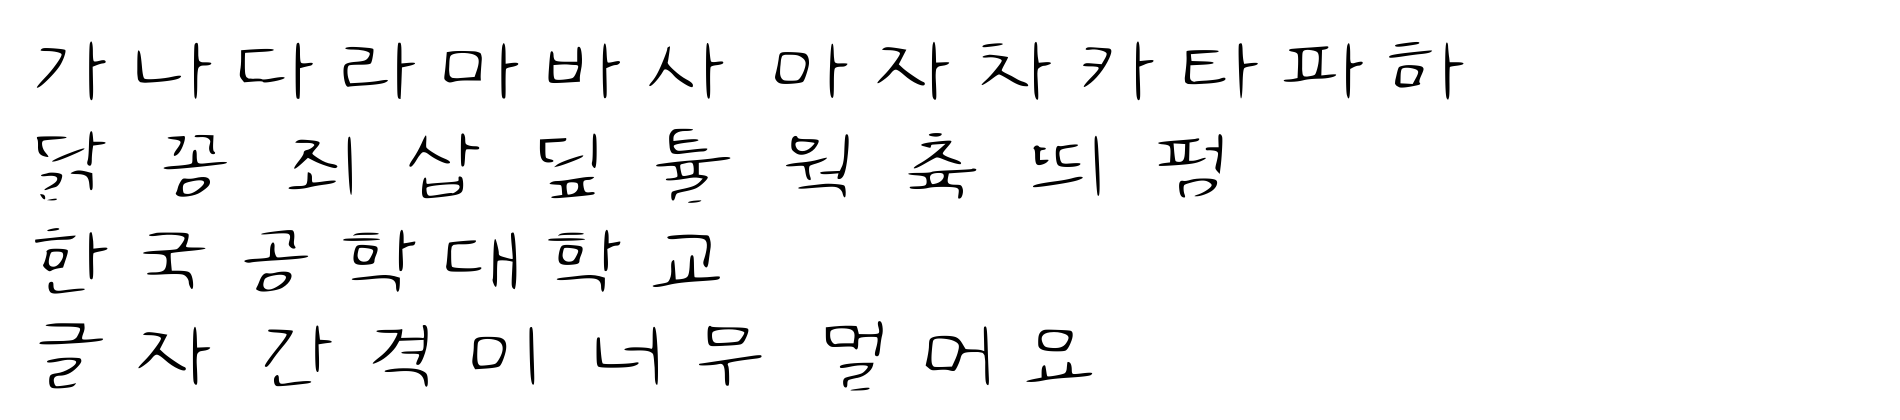

In [ ]:
from PIL import Image, ImageDraw, ImageFont
from IPython.display import display

font_path = "/content/CEHandKRFinal.ttf"

img = Image.new("RGB", (1900, 420), "white")
draw = ImageDraw.Draw(img)
font = ImageFont.truetype(font_path, 80)

lines = [
    "가나다라마바사 아자차카타파하",
    "닭 꽁 죄 삽 딮 튤 웍 츅 띄 펌",
    "한국공학대학교",
    "글자 간격이 너무 멀어요"
]

y = 30
for line in lines:
    draw.text((20, y), line, font=font, fill="black")
    y += 95

display(img)

In [ ]:
from fontTools.ttLib import TTFont

src = "/content/CEHandKRFinal.ttf"
dst = "/content/CEHandKRFinal_clean.ttf"

font = TTFont(src)
name_table = font["name"]

# 유지할 이름 값
replace_map = {
    1: {
        "en": "CE Hand KR Final",
        "ko": "채은손글씨",
    },
    2: {
        "en": "Regular",
        "ko": "Regular",
    },
    4: {
        "en": "CE Hand KR Final Regular",
        "ko": "채은손글씨 Regular",
    },
    6: {
        "en": "CEHandKRFinal-Regular",
        "ko": "CEHandKRFinal-Regular",
    },
    16: {
        "en": "CE Hand KR Final",
        "ko": "채은손글씨",
    },
    17: {
        "en": "Regular",
        "ko": "Regular",
    },
    18: {
        "en": "CE Hand KR Final",
        "ko": "채은손글씨",
    },
    7: {
        "en": "Modified from NanumGothic under SIL Open Font License.",
        "ko": "NanumGothic(OFL)를 기반으로 수정된 폰트입니다.",
    },
    20: {
        "en": "CEHandKRFinal-Regular",
        "ko": "CEHandKRFinal-Regular",
    },
}

for record in name_table.names:
    lang = "ko" if record.langID == 1042 else "en"
    if record.nameID in replace_map:
        new_value = replace_map[record.nameID][lang]
        record.string = new_value.encode("utf-16-be")

font.save(dst)
print("저장 완료:", dst)

저장 완료: /content/CEHandKRFinal_clean.ttf


In [ ]:
from fontTools.ttLib import TTFont

tt = TTFont("/content/CEHandKRFinal_clean.ttf")
for record in tt["name"].names:
    try:
        value = record.toUnicode()
    except:
        value = record.string
    if "Nanum" in str(value) or "나눔" in str(value) or "CE Hand" in str(value) or "채은손글씨" in str(value):
        print(record.nameID, record.platformID, record.platEncID, record.langID, value)

1 1 0 0 CE Hand KR Final
4 1 0 0 CE Hand KR Final Regular
7 1 0 0 Modified from NanumGothic under SIL Open Font License.
16 1 0 0 CE Hand KR Final
18 1 0 0 CE Hand KR Final
1 3 1 1033 CE Hand KR Final
4 3 1 1033 CE Hand KR Final Regular
7 3 1 1033 Modified from NanumGothic under SIL Open Font License.
16 3 1 1033 CE Hand KR Final
18 3 1 1033 CE Hand KR Final
1 3 1 1042 채은손글씨
4 3 1 1042 채은손글씨 Regular
16 3 1 1042 채은손글씨
18 3 1 1042 채은손글씨


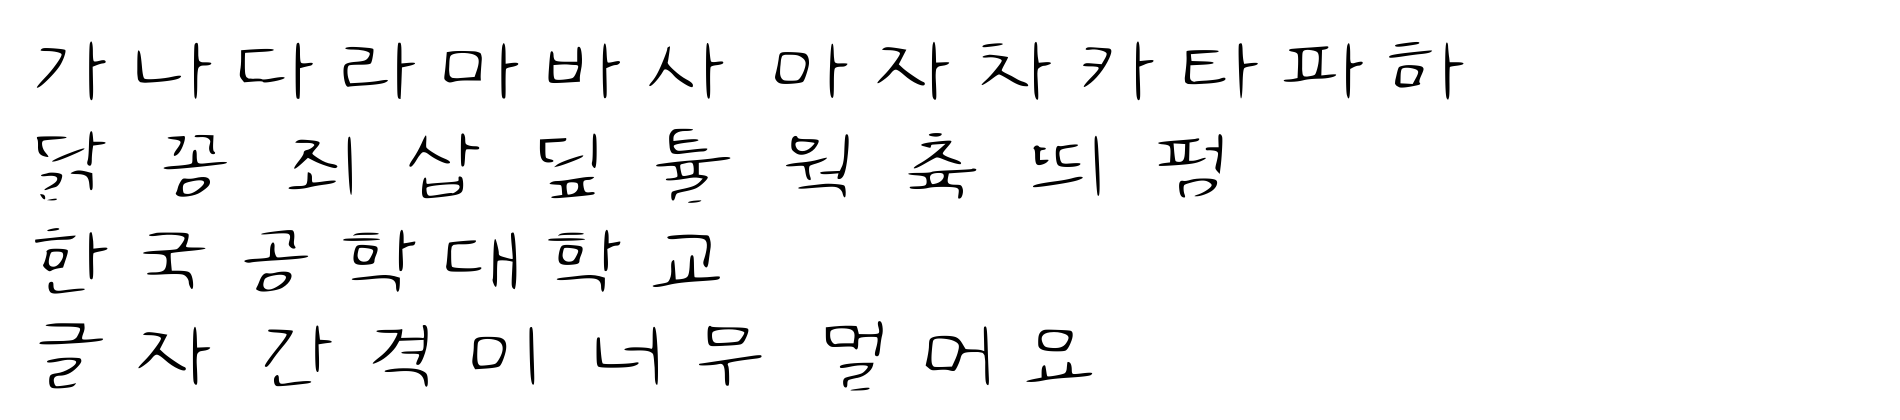

In [ ]:
from PIL import Image, ImageDraw, ImageFont
from IPython.display import display

font_path = "/content/CEHandKRFinal.ttf"

img = Image.new("RGB", (1900, 420), "white")
draw = ImageDraw.Draw(img)
font = ImageFont.truetype(font_path, 80)

lines = [
    "가나다라마바사 아자차카타파하",
    "닭 꽁 죄 삽 딮 튤 웍 츅 띄 펌",
    "한국공학대학교",
    "글자 간격이 너무 멀어요"
]

y = 30
for line in lines:
    draw.text((20, y), line, font=font, fill="black")
    y += 95

display(img)

In [ ]:
from google.colab import files
files.download("/content/CEHandKRFinal.ttf")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>